## Examples of agent mistakes

Scratch notebook for studying the kinds of mistakes the coding agents make when reformatting the eval datasets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import seaborn as sns
sns.set_theme(style="ticks", rc={"axes.spines.right": False, "axes.spines.top": False})
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from utils import load_all

data = load_all()

### Difference-category tag counts

Each `eval/<dataset>/report.md` has a "Difference categories" column on the per-question table where I tag the *kind* of disagreement between trials with entries like `` `VARNAME=6` `` or `` `MISC=1` ``. Only entries with the `LABEL=N` form are counted (bare labels like `` `MISC` `` or `` `SEMANTIC` `` are skipped — they're informal). The total per label is the sum of the `N` values across all 8 reports.

In [2]:
import re
from pathlib import Path
from collections import defaultdict

EVAL_DIR = Path(".").resolve()
DATASETS = ["allen2p", "chen2024", "hasnain2024", "lee2025",
            "majnik2025", "sosa2024", "zhang2025", "zhong2025"]

# Match LABEL=N in or out of backticks. Skips bare labels by requiring "=<int>".
TAG_RE = re.compile(r"([A-Z_][A-Z0-9_]*)=(\d+)")

# Map raw report tags to the canonical category names used in the figure
# / definitions. Both legacy spellings (TIMERES, RESAMP) collapse to
# TIME_RES.
TAG_ALIASES = {
    "RESAMP":  "TIME_RES",
    "TIMERES": "TIME_RES",
}


def _diff_cat_cells(report_path):
    """Yield the raw text of the Difference-categories column for each Q row."""
    in_table = False
    header_cols = None
    for line in report_path.read_text().splitlines():
        if not line.startswith("|"):
            in_table = False
            continue
        cells = [c.strip() for c in line.strip().strip("|").split("|")]
        if header_cols is None or not in_table:
            if any("Difference" in c for c in cells):
                header_cols = cells
                in_table = True
            continue
        # Skip the |---|---| separator row
        if all(set(c) <= set("-: ") for c in cells):
            continue
        try:
            idx = header_cols.index(next(c for c in header_cols if "Difference" in c))
        except (ValueError, StopIteration):
            continue
        if idx < len(cells):
            yield cells[idx]


per_dataset_tags = defaultdict(lambda: defaultdict(int))   # ds -> tag -> count
totals = defaultdict(int)                                  # tag -> count

for ds in DATASETS:
    path = EVAL_DIR / ds / "report.md"
    for cell in _diff_cat_cells(path):
        for label, n in TAG_RE.findall(cell):
            label = TAG_ALIASES.get(label, label)
            per_dataset_tags[ds][label] += int(n)
            totals[label] += int(n)

summary = (pd.DataFrame(per_dataset_tags)
           .reindex(columns=DATASETS)
           .fillna(0).astype(int))
summary["TOTAL"] = summary.sum(axis=1)
summary = summary.sort_values("TOTAL", ascending=False)
summary.loc["TOTAL"] = summary.sum(axis=0)
summary

,allen2p,chen2024,hasnain2024,lee2025,majnik2025,sosa2024,zhang2025,zhong2025,TOTAL
PROCESS,0,5,12,2,2,0,0,4,25
ASSUME,0,0,0,5,0,7,8,0,20
FILTER,0,4,0,4,0,0,3,6,17
VARNAME,6,2,4,0,0,0,0,0,12
MISC,5,0,1,0,3,0,0,1,10
TIME_RES,6,0,0,0,0,1,2,0,9
TOTAL,17,11,17,11,5,8,13,11,93


#### Category definitions

- **FILTER** — Inconsistent or unjustified choices when **filtering data** (trials, neurons/units, sessions). Covers both *which* criterion to apply (spike-rate cutoff, ISI-violation threshold, behavioral exclusion rule, project-code filter) and *what value* to use, especially when the paper does not explicitly prescribe one. Also includes deciding what data to ignore given the context of the paper's analysis.
- **TIME_RES** — Inconsistent choices about **temporal representation**: time-bin width, output sampling rate, whether to upsample / downsample / leave at native rate, and how to align streams that arrive at different rates.
- **PROCESS** — Mistakes that show up when the requested output variable requires **non-trivial processing** from the raw data — e.g., combining multiple raw streams, computing a derived quantity (velocity from position, motion energy from frames, distance to landmark), unit conversion, event detection. Failures are usually that the agent picked an incorrect or sub-optimal procedure, not that they failed to find the data.
- **ASSUME** — Wrong **assumptions about what the data contains or means**, made without checking the assumption against the data itself. Sources include skimming the paper/methods and over-interpreting; defaulting to a "common-case" convention that doesn't apply to this dataset; treating a sign convention, coordinate system, or unit as given. Distinguished from PROCESS in that the error is a *belief* about the data, not a faulty *procedure*.
- **VARNAME** — A special case of **ASSUME** where the agent inferred a variable's meaning purely from its name in the raw data without verifying against actual values or upstream code (e.g., a column called `position` that actually stores wheel-encoder ticks; an `image_id` field whose integer index does not map directly to image identity).
- **MISC** — Mistakes that don't fit the above categories. Used sparingly.

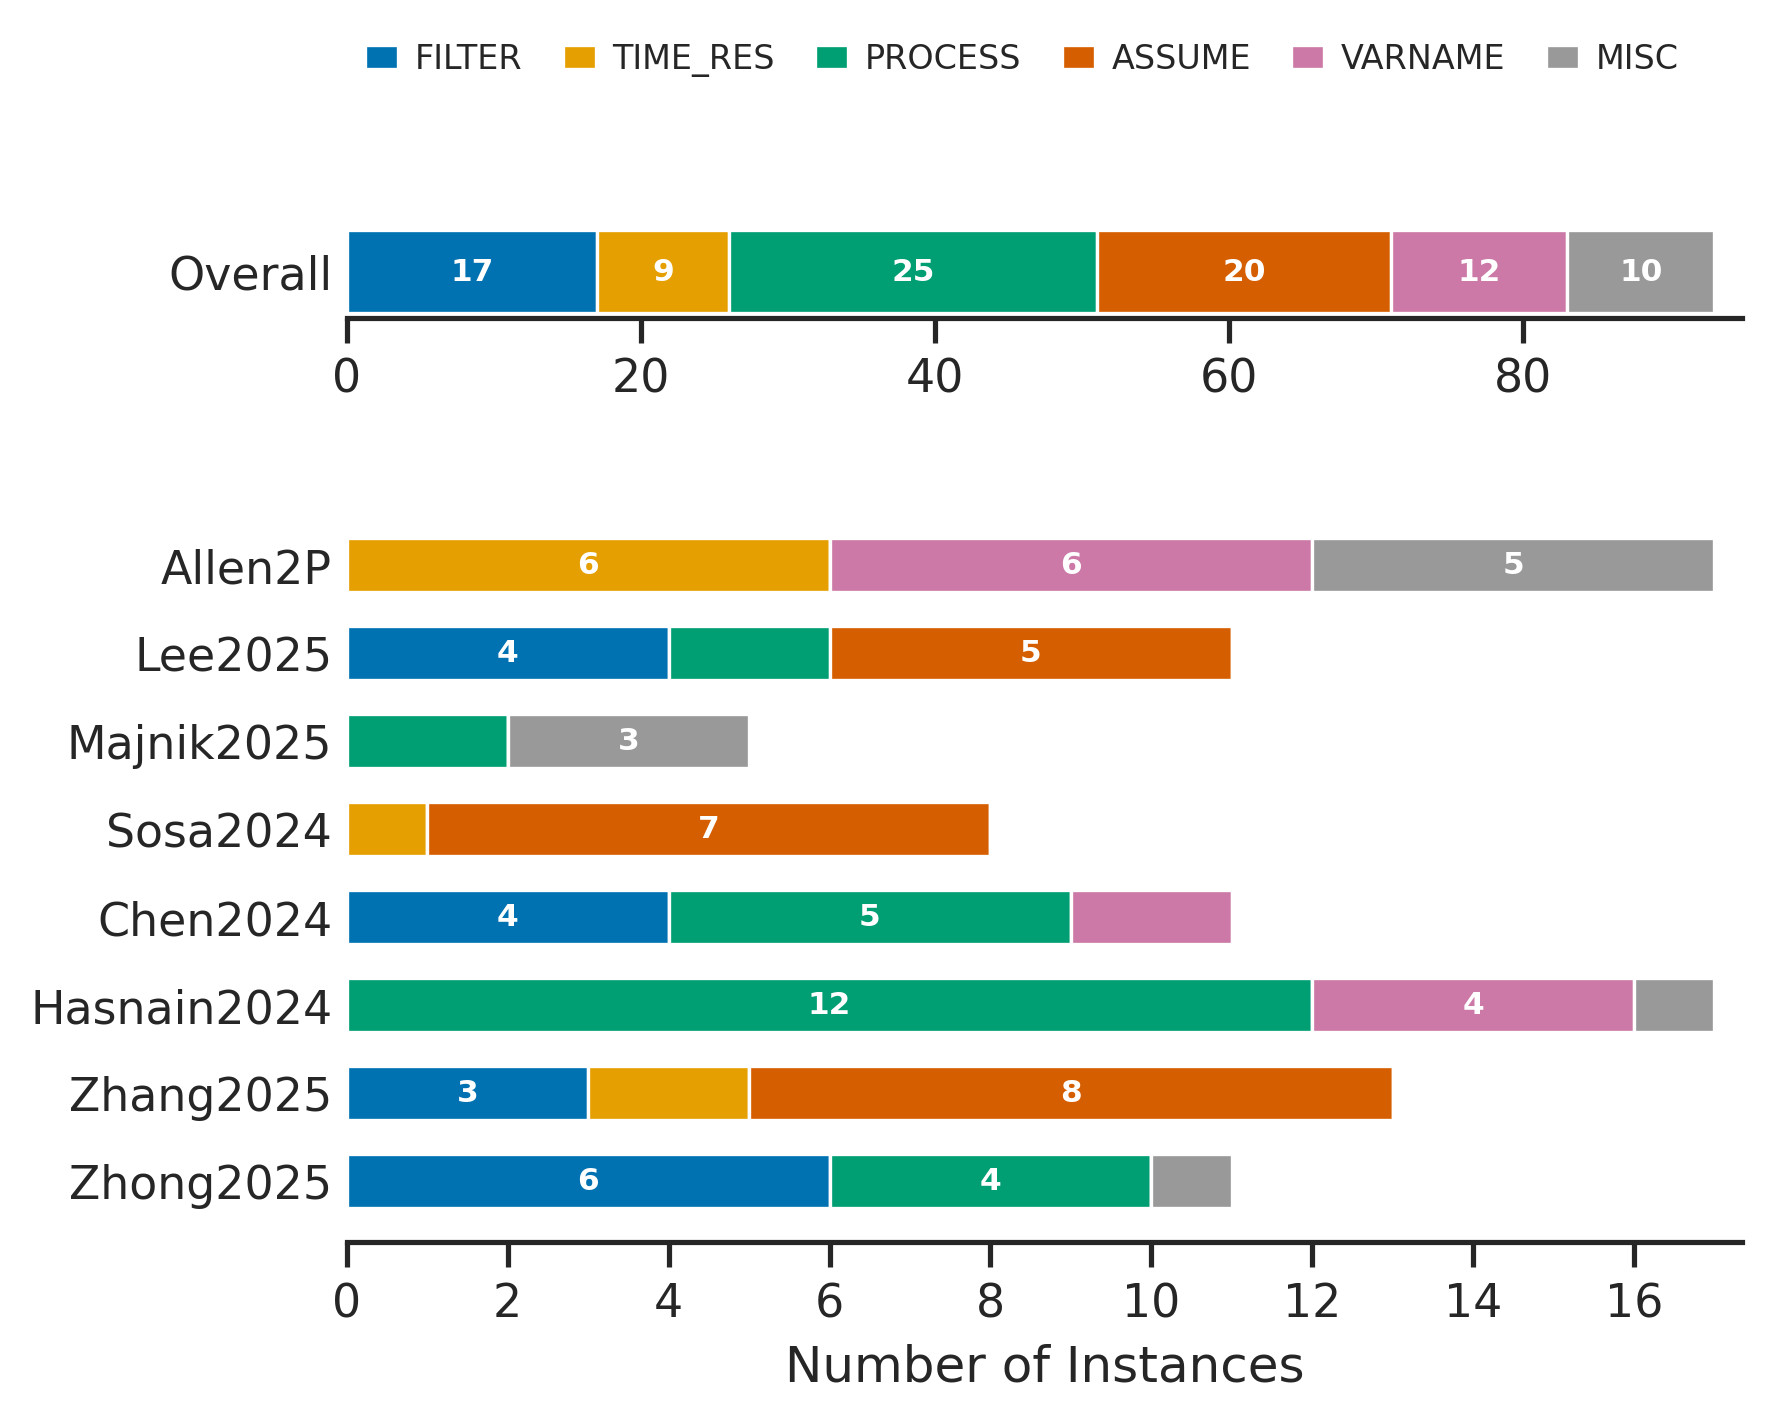

In [3]:
# Per-dataset stacked horizontal bar — error-category breakdown.
# Top panel: a single "Overall" bar summing every dataset (own x-scale).
# Bottom panel: one bar per dataset, ordered like the summary table
# (supervised first, then unsupervised, top→bottom).
# Categories stacked left→right in the legend's order.

CAT_ORDER = ["FILTER", "TIME_RES", "PROCESS", "ASSUME", "VARNAME", "MISC"]

# Same supervised-then-unsupervised ordering used in the summary table.
DS_ORDER = ["allen2p", "lee2025", "majnik2025", "sosa2024",
            "chen2024", "hasnain2024", "zhang2025", "zhong2025"]

ds_mat = (summary
          .drop(index="TOTAL", columns="TOTAL")    # categories × datasets
          .T                                        # datasets × categories
          .reindex(index=DS_ORDER, columns=CAT_ORDER)
          .fillna(0).astype(int))
total_row = ds_mat.sum(axis=0)

DISPLAY_NAME = {"allen2p": "Allen2P"}
def _disp(ds): return DISPLAY_NAME.get(ds, ds[:1].upper() + ds[1:])

# Okabe-Ito qualitative palette — designed for color-vision-deficient
# readers (deutan / protan / tritan all distinguishable). Yellow and
# black skipped because the inline cell labels are white-on-color and
# need enough contrast. MISC = neutral gray to visually de-emphasise the
# "other" bucket.
palette = [
    "#0072B2",  # FILTER   — blue
    "#E69F00",  # TIME_RES — orange
    "#009E73",  # PROCESS  — bluish green
    "#D55E00",  # ASSUME   — vermillion
    "#CC79A7",  # VARNAME  — reddish purple
    "#999999",  # MISC     — neutral gray
]
cat_colors = dict(zip(CAT_ORDER, palette))


def _draw_stack(ax, mat, y_positions, label_thresh=3):
    """Draw stacked horizontal bars for each row of `mat` (DataFrame)."""
    left = np.zeros(len(y_positions))
    for cat in CAT_ORDER:
        vals = mat[cat].to_numpy(dtype=float)
        ax.barh(y_positions, vals, left=left, height=0.62,
                color=cat_colors[cat], edgecolor="white", linewidth=0.8,
                label=cat)
        for yi, xi, v in zip(y_positions, left, vals):
            if v >= label_thresh:
                ax.text(xi + v / 2, yi, str(int(v)),
                        ha="center", va="center", fontsize=7.5,
                        color="white", fontweight="bold")
        left += vals
    return left


fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(6.0, 4.4),
    gridspec_kw={"height_ratios": [1, len(DS_ORDER)], "hspace": 0.45},
)

# --- Top: total summary, own x-axis ---
total_left = _draw_stack(ax_top, total_row.to_frame().T, [0])
ax_top.set_yticks([0], ["Overall"])
ax_top.set_xlim(0, total_left[0] * 1.02)
ax_top.tick_params(axis="y", length=0)
ax_top.spines["left"].set_visible(False)

# --- Bottom: per-dataset (DS_ORDER reads top→bottom → reverse y) ---
ds_y = np.arange(len(DS_ORDER))[::-1]
ds_left = _draw_stack(ax_bot, ds_mat, ds_y)
ax_bot.set_yticks(ds_y, [_disp(ds) for ds in DS_ORDER])
ax_bot.set_xlim(0, ds_left.max() * 1.02)
ax_bot.tick_params(axis="y", length=0)
ax_bot.spines["left"].set_visible(False)
ax_bot.set_xlabel("Number of Instances")

# Single shared legend above the top panel.
handles, labels = ax_top.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(CAT_ORDER), frameon=False, fontsize=8,
           handlelength=1.0, handletextpad=0.5, columnspacing=1.2)

# plt.savefig("error_category.pdf", bbox_inches="tight", dpi=300)
plt.show()

### Agents are inconsistent when they make mistakes

The tag counts above show *what kinds* of mistakes happen. The two histograms below show that mistakes are also **stochastic** — the same agent on the same question often gets different ratings across the 3 repeat trials.

- **Per-question min − max** (one point per sub-question): how far apart the worst trial is from the best trial. `0` means all trials agreed exactly; the more negative, the more an agent's runs disagreed with each other.
- **Per-trial Δmax** (one point per trial): each trial's rating minus the best rating achieved on that sub-question. `0` means the trial was as good as the best run; negative means it under-performed its sibling trials.

Same construction as `analysis.ipynb` cells `25c6e7d3` / `838d2c72`, just transplanted here so this notebook stands alone.

In [4]:
# Build eval_quality the same way analysis.ipynb does:
#   - prune tautological vars (sosa2024 Q3-5, hasnain2024 Q4-5)
#   - drop Code Efficiency (advice, not a correctness check)
#   - drop questions outside the categorize() taxonomy (defensive — currently none)
# Result: one row per (dataset, qid, agent, trial), with the four rater
# columns (human / claude / codex / best) aligned.
from utils import categorize

TAUTOLOGICAL = {
    "sosa2024":    ["3", "4", "5"],
    "hasnain2024": ["4", "5"],
}
for ds, qs in TAUTOLOGICAL.items():
    for q in qs:
        data[ds].pop(q, None)

EVAL_QUALITY_EXCLUDE = {"Code Efficiency"}

records = []
for ds, mains in data.items():
    for main, subs in mains.items():
        for sub_letter, q in subs.items():
            qid = f"{main}-{sub_letter}" if sub_letter else main
            cat = categorize(qid, q["title"])
            if cat is None or cat[0] in EVAL_QUALITY_EXCLUDE:
                continue
            for i, agent in enumerate(q["agents"]):
                records.append({
                    "dataset": ds,
                    "qid": qid,
                    "agent": agent,
                    "trial": int(q["trials"][i]),
                    "human":  q["human"][i],
                    "claude": q["claude"][i],
                    "codex":  q["codex"][i],
                    "best":   q["best_rating"][i],
                })
eval_quality = pd.DataFrame(records)
print(f"{len(eval_quality)} (dataset, qid, agent, trial) rows")

1014 (dataset, qid, agent, trial) rows


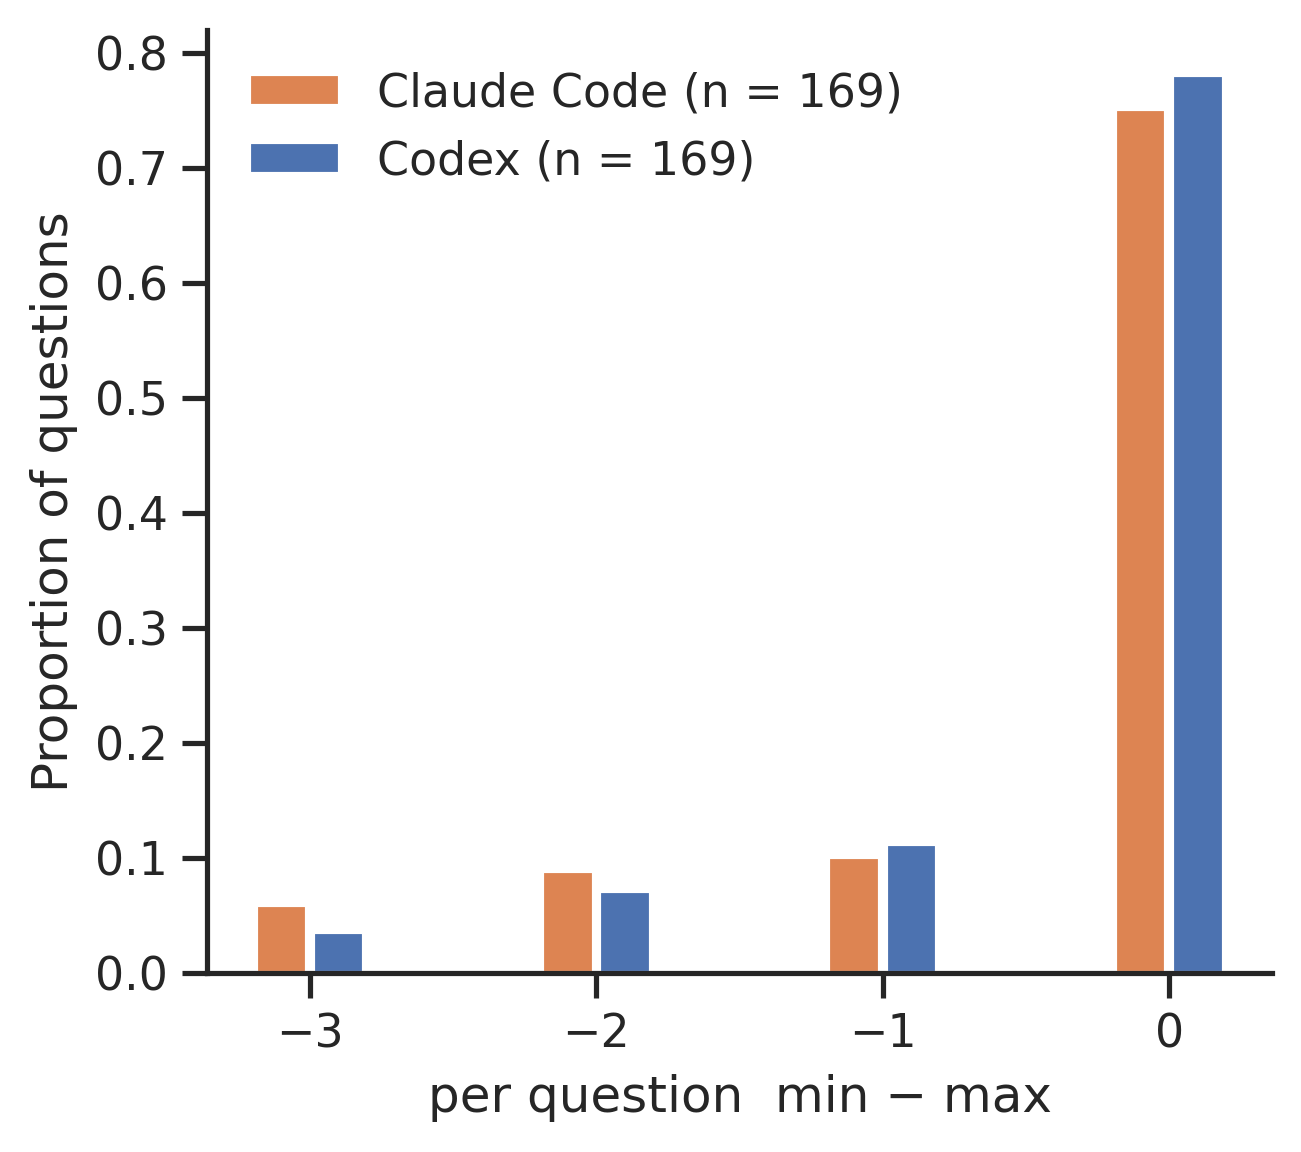

In [5]:
# Trial variability — plot 1: per sub-question, the spread (min − max) of
# `best` ratings across its trials. One data point per sub-question.
# Spread is ≤ 0; 0 means all 3 repeat trials agreed exactly.
# Grouped bars: Claude Code vs Codex, 3 trials per sub-q each.

def spread_per_subq(df):
    g = df.groupby(["dataset", "qid"])["best"]
    return (g.min() - g.max()).dropna().to_numpy()

claude_spread = spread_per_subq(eval_quality[eval_quality["agent"] == "claude-code"])
codex_spread  = spread_per_subq(eval_quality[eval_quality["agent"] == "codex"])

bin_edges = np.arange(-3.5, 1.5, 1)
centers   = (bin_edges[:-1] + bin_edges[1:]) / 2          # -3, -2, -1, 0
bar_w     = 0.18                                          # thin bars
offset    = bar_w / 2 + 0.01

claude_h, _ = np.histogram(claude_spread, bins=bin_edges, density=True)
codex_h,  _ = np.histogram(codex_spread,  bins=bin_edges, density=True)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(centers - offset, claude_h, width=bar_w, color="C1",
       label=f"Claude Code (n = {len(claude_spread)})")
ax.bar(centers + offset, codex_h,  width=bar_w, color="C0",
       label=f"Codex (n = {len(codex_spread)})")
ax.set_xticks(np.arange(-3, 1))
ax.set_xlabel("per question  min − max")
ax.set_ylabel("Proportion of questions")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
# plt.savefig("variability.pdf", bbox_inches="tight", dpi=300)
plt.show()

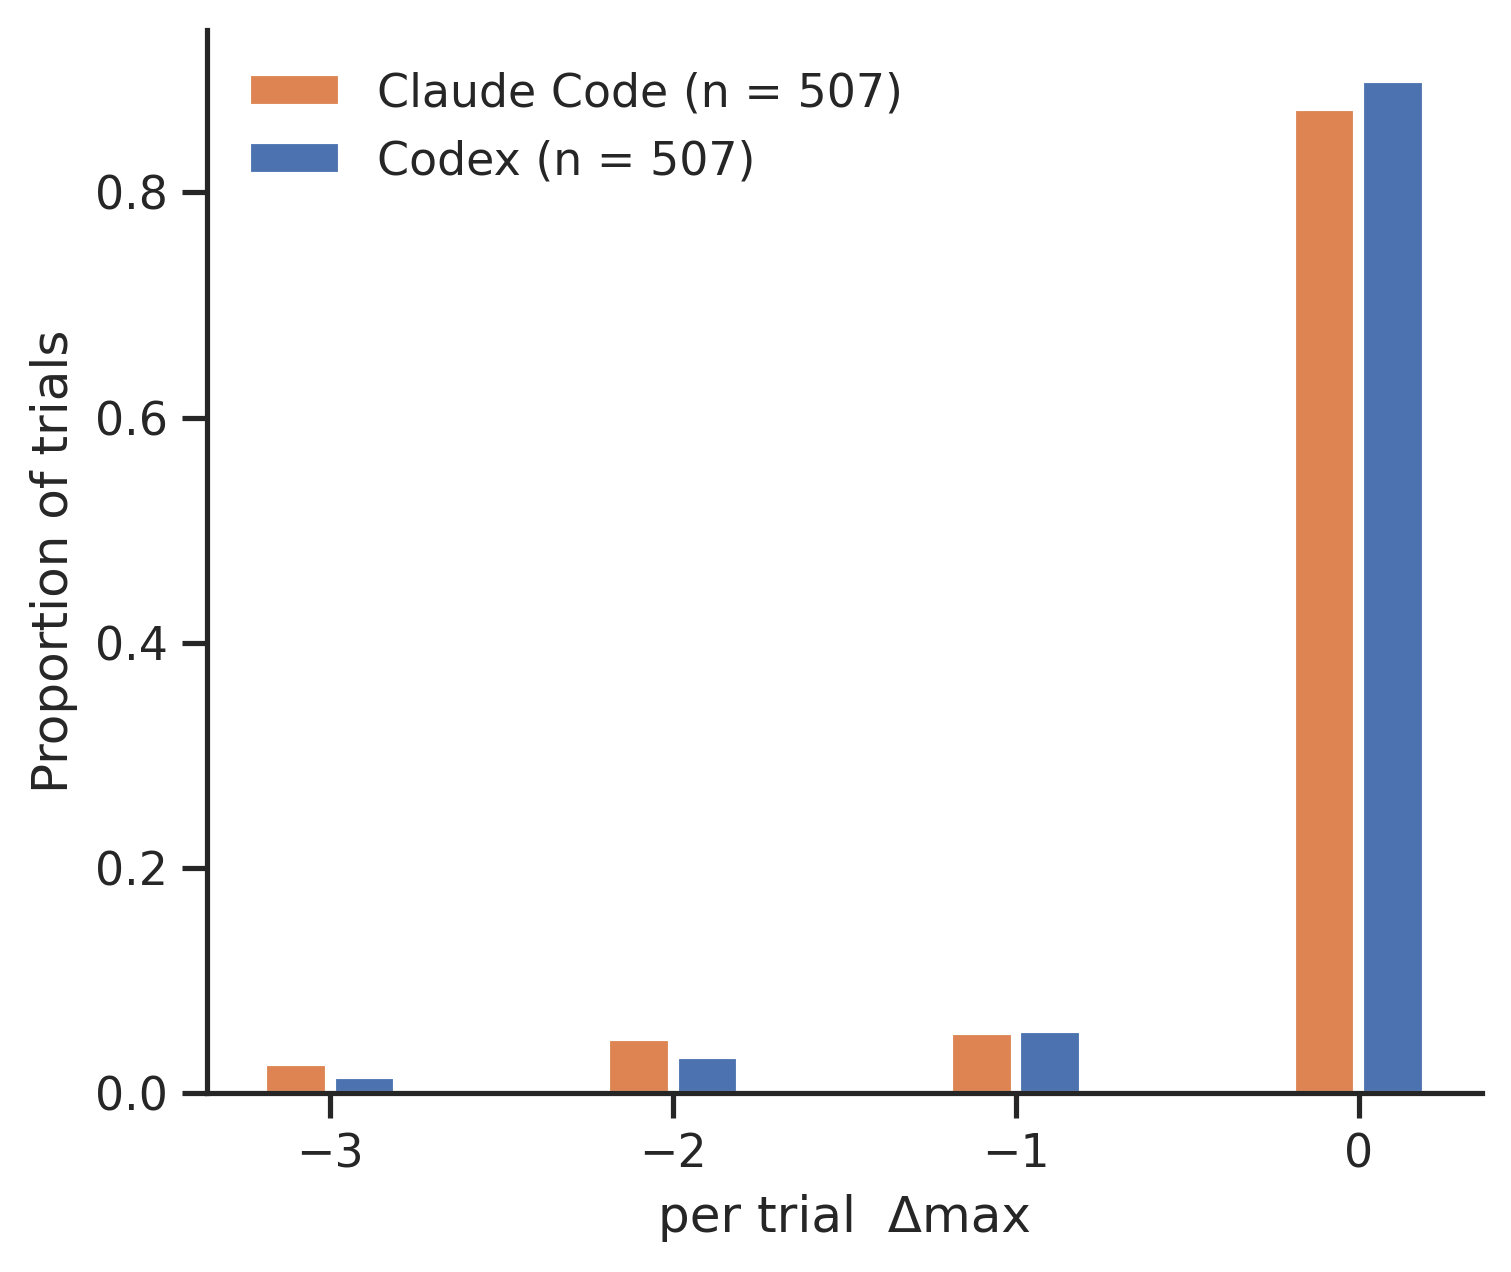

In [6]:
# Trial variability — plot 2: per sub-question, each trial's `best` rating
# minus the max across trials in that sub-question. n trials per sub-q,
# so total points = (n_subq × n_trials_per_subq).
# 0 = trial achieved the per-sub-q best; negative = below best.
# Grouped bars: Claude Code vs Codex, 3 trials per sub-q each.

def trial_minus_max(df):
    g = df.groupby(["dataset", "qid"])["best"]
    return (df["best"] - g.transform("max")).dropna().to_numpy()

claude_dmax = trial_minus_max(eval_quality[eval_quality["agent"] == "claude-code"])
codex_dmax  = trial_minus_max(eval_quality[eval_quality["agent"] == "codex"])

bin_edges = np.arange(-3.5, 1.5, 1)
centers   = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_w     = 0.18
offset    = bar_w / 2 + 0.01

claude_h, _ = np.histogram(claude_dmax, bins=bin_edges, density=True)
codex_h,  _ = np.histogram(codex_dmax,  bins=bin_edges, density=True)

# Height = 4.4 in to match the stacked-bar count plot above.
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.bar(centers - offset, claude_h, width=bar_w, color="C1",
       label=f"Claude Code (n = {len(claude_dmax)})")
ax.bar(centers + offset, codex_h,  width=bar_w, color="C0",
       label=f"Codex (n = {len(codex_dmax)})")
ax.set_xticks(np.arange(-3, 1))
ax.set_xlabel("per trial  Δmax")
ax.set_ylabel("Proportion of trials")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

### Case Study / Examples

The cells below walk through individual failure cases that illustrate the broader categories from the figure above. Each example follows the same template:

- **Title** — `#### Example N: Dataset - CATEGORY`. Compact and sequentially numbered; the LaTeX export drops the `Example N:` prefix and lets `amsthm` assign the number.
- **Task:** What the agent is asked to deliver, the dataset context needed to understand the question, and what the **nominally correct** decision is. We do not repeat the verbatim question text from `DECISIONS.md`.
- **Summary:** A short paragraph explaining what went wrong and why it matters across the 6 trials.
- **Trial summary table.** One row per repeat trial (6 total: 3 Claude Code × 3 Codex), summarising what each agent chose so the reader can see the spread at a glance. Rows whose rating is `incorrect` are shaded red and `concerning` rows are shaded yellow in the LaTeX output.
- **Code Snippets:** A bold mini-heading, followed by 2–3 labelled snippets (~10–15 lines each) drawn from the actual `convert_data.py` files; line numbers and file paths are stripped. Each snippet is followed by one or two sentences explaining what it does and why.

Trials are labelled "Claude Code, Trial *N*" and "Codex, Trial *N*".

#### Example 1: Allen2P - TIME_RES

**Task:** The agent must deliver per-trial neural traces aligned to stimulus events and decide what temporal grid to put them on. Sessions come from two rigs with different acquisition rates — Scientifica single-plane (~31 Hz) and Multiscope multi-plane (~11 Hz) — and the released NWB files contain pre-computed dF/F traces sampled at the native rate. Because the trial windows are already frame-aligned, the **nominally correct** decision is to leave the dF/F at its native rate and not resample at all. Resampling onto a fixed grid (e.g. 30 Hz, ~33 ms) is a defensible second choice for unifying across rigs, but it is not required by the task. Anything that significantly *coarsens* the data — or applies an operation other than averaging — discards information.

**Summary:** Six trials produced four distinct answers for the temporal resolution of the neural data, ranging from no resampling at all to an 8× downsample, and two of them used operations (hard rebinning into stimulus-aligned windows; summing events instead of averaging) that change the *meaning* of the per-bin values rather than just the resolution. None of the agents recognised that the trial windows are already frame-aligned, so no resampling is necessary in the first place.

| Trial | Bin / Rate | Operation | Rating |
|---|---|---|---|
| Claude Code, Trial 1 | native (~11 / 31 Hz) | none | match |
| Claude Code, Trial 2 | 750 ms | mean | incorrect |
| Claude Code, Trial 3 | 30 Hz | linear interp | ok |
| Codex, Trial 1 | 100 ms | sum of events | concerning |
| Codex, Trial 2 | 30 Hz | linear interp | ok |
| Codex, Trial 3 | 30 Hz | linear interp | ok |

**Code Snippets:**

*Claude Code, Trial 1 — keep native rate, no resampling:*
```python
dt = np.median(np.diff(ophys_ts))   # native frame interval, ~32 ms

frame_mask = (ophys_ts >= t_start) & (ophys_ts < t_stop)
trial_ts   = ophys_ts[frame_mask]
neural     = dff[:, frame_mask].astype(np.float32)
```
The dF/F frames inside each trial window are taken as-is — no interpolation, no rebinning. The per-session bin size is just the median inter-frame interval.

*Claude Code, Trial 2 — fixed 750 ms bin, one per stimulus flash:*
```python
TIME_BIN_MS   = 750.0   # 250 ms image + 500 ms grey
bin_duration  = TIME_BIN_MS / 1000.0
all_stim_ends = stim_start + bin_duration

ophys_bin_starts = np.searchsorted(ophys_ts, stim_start,    side='left')
ophys_bin_ends   = np.searchsorted(ophys_ts, all_stim_ends, side='left')

dff_cumsum = np.cumsum(dff_valid, axis=0)
dff_cumsum = np.vstack([np.zeros((1, n_neurons)), dff_cumsum])
for bi, si in enumerate(trial_stim_indices):
    s, e = ophys_bin_starts[si], ophys_bin_ends[si]
    if e > s:
        neural_matrix[:, bi] = (dff_cumsum[e] - dff_cumsum[s]) / (e - s)
```
Collapses the trace to a *single* value per stimulus presentation. For an ~11 Hz Multiscope session this is roughly an 8× downsample, and all within-flash dynamics — the signal of interest in this task — are averaged away.

*Codex, Trial 1 — fixed 100 ms bin, summed events:*
```python
BIN_SIZE_SEC = 0.1
starts = np.arange(start_time, stop_time, BIN_SIZE_SEC)
ends   = np.minimum(starts + BIN_SIZE_SEC, stop_time)

frame_starts = np.searchsorted(ophys_timestamps, starts, side="left")
frame_ends   = np.searchsorted(ophys_timestamps, ends,   side="left")

neural_trial = np.zeros((n_neurons, len(starts)), dtype=np.float32)
for b in range(len(starts)):
    lo, hi = int(frame_starts[b]), int(frame_ends[b])
    if hi > lo:
        neural_trial[:, b] = event_data[lo:hi].sum(axis=0)
```
A 100 ms bin is reasonable for the 30 Hz behavior streams, but for 11 Hz Multiscope sessions most bins contain only one or zero ophys frames. Using `sum` rather than `mean` then makes each bin's value implicitly scale with how many frames happened to land in the window — a different operation would have made this a benign resampling.

#### Example 2: Hasnain2024 - VARNAME

**Task:** The agent must produce a per-trial label of which side the mouse actually licked. The raw data is a Matlab struct in which `obj.bp.R` and `obj.bp.L` hold per-trial booleans. Their *names* suggest they encode the lick direction the mouse made, but in fact they encode the **instructed** side for that trial — i.e. the trial's correct answer, set by the task before the mouse responded. The actual lick direction must be derived: either by combining the instruction with the trial outcome (`bp.hit` / `bp.miss`), since `R & hit` and `L & miss` both correspond to a rightward lick; or by reading the timed lick events in `bp.ev.lickL` / `bp.ev.lickR` and taking the side of the first lick after the go cue. The **nominally correct** decision is to derive the response from one of these two sources — anything that uses `bp.R` directly reports the instructed direction, which silently turns into the *correct* label rather than the *observed* one.

**Summary:** Four out of six trials took `bp.R` at face value as the lick direction, on the strength of its name alone. The two correct trials each consulted a different source: Claude Code, Trial 1 combined the instruction with trial outcome, and Codex, Trial 2 read the per-trial lick-event arrays. None of the four incorrect trials checked the variable's meaning against the surrounding fields (`hit` / `miss`, `lickL` / `lickR`) before using it.

| Trial | Source | Approach | Rating |
|---|---|---|---|
| Claude Code, Trial 1 | `bp.R`, `bp.L`, `bp.hit`, `bp.miss` | `(R & hit)` or `(L & miss)` -> right | match |
| Claude Code, Trial 2 | `bp.R` | use directly | incorrect |
| Claude Code, Trial 3 | `bp.R` | use directly | incorrect |
| Codex, Trial 1 | `bp.R` | use directly | incorrect |
| Codex, Trial 2 | `bp.ev.lickL`, `bp.ev.lickR` | first lick after go cue | match |
| Codex, Trial 3 | `bp.R` | use directly | incorrect |

**Code Snippets:**

*Claude Code, Trial 2 — `bp.R` taken as the lick direction:*
```python
# --- Extract trial-level variables ---
valid_trial_indices = valid_trials - 1
lick_direction = bp['R'][valid_trial_indices].copy()
```
Reads `bp.R` straight into `lick_direction`, treating the instructed side as if it were the side the mouse licked. The other three incorrect trials do essentially the same thing in one or two lines.

*Claude Code, Trial 1 — derive actual response from instruction × outcome:*
```python
R    = np.array(bp['R']).flatten().astype(bool)
L    = np.array(bp['L']).flatten().astype(bool)
hit  = np.array(bp['hit']).flatten().astype(bool)
miss = np.array(bp['miss']).flatten().astype(bool)

lick_right     = (R & hit) | (L & miss)
lick_direction = lick_right[valid_trials].astype(np.int32)
```
Combines the instructed side with whether the mouse was correct: a right lick is either a correct R-trial (`R & hit`) or an error L-trial (`L & miss`). Recovers the actual response without needing the timed lick events.

*Codex, Trial 2 — read the per-trial lick-event arrays:*
```python
def get_first_lick_direction(obj, trial_idx, go_time):
    lick_l = event_list_to_array(obj["bp"]["ev"]["lickL"][trial_idx])
    lick_r = event_list_to_array(obj["bp"]["ev"]["lickR"][trial_idx])
    lick_l = lick_l[lick_l >= go_time]
    lick_r = lick_r[lick_r >= go_time]
    first_l = lick_l[0] if lick_l.size else math.inf
    first_r = lick_r[0] if lick_r.size else math.inf
    if math.isinf(first_l) and math.isinf(first_r):
        return None
    return 0 if first_l < first_r else 1
```
Pulls the timed lick events on each side, restricts to those after the go cue, and returns the side of the first one — the most direct read of the actual response.

#### Example 3: Zhong2025 - FILTER

**Task:** The agent must decide which neurons to include in the output `neural` matrix. The dataset is two-photon imaging of mouse cortex (V1, mHV, lHV, aHV) during a virtual-corridor task with reward-predictive cues, and the released `*_neural_data.npy` files contain Suite2p-detected, deconvolved spike traces for every detected neuron. The reference code applies **no neuron-level quality control**: all Suite2p neurons are kept, and a region label (V1 / mHV / lHV / aHV / other) is attached separately as metadata. Selectivity-based subsetting (corridor-responsive cells, stimulus-selective cells, reward-prediction cells, etc.) is an *analysis-time* choice, made downstream of the converted data, not a data-format choice. The **nominally correct** decision is therefore to keep every Suite2p neuron and let the analysis decide which subset to use.

**Summary:** All three Claude Code trials kept every Suite2p neuron (correct). All three Codex trials, by contrast, applied aggressive selectivity-based filters before output — and each trial used a *different* criterion. Trial 1 restricted to {V1, mHV, lHV, aHV} and added a per-area corridor-responsiveness × d' filter; Trial 2 added a rewarded-vs-non-rewarded d' threshold unioned with an aHV reward-prediction set; Trial 3 went furthest, dropping V1 and lHV entirely and keeping only mHV neurons in the top/bottom 5% on familiar-stimulus d' (plus an aHV reward-prediction set, with a fallback to the top 128 mHV neurons). The same agent on the same question produced three incompatible neuron populations, and one of them excludes the dataset's primary visual area.

| Trial | Neuron filter | Rating |
|---|---|---|
| Claude Code, Trial 1 | none — all Suite2p neurons kept | ok |
| Claude Code, Trial 2 | none | match |
| Claude Code, Trial 3 | none | ok |
| Codex, Trial 1 | restrict to V1/mHV/lHV/aHV; per-area corridor-resp. + d' selectivity | concerning |
| Codex, Trial 2 | visual cortex; rewarded-vs-non-rewarded d' >= 0.3, plus aHV reward-pred | concerning |
| Codex, Trial 3 | mHV only (top/bottom 5% on stim d'), plus aHV reward-pred — **drops V1, lHV** | incorrect |

**Code Snippets:**

*Claude Code, Trial 1 — no QC filter; region label attached as metadata:*
```python
# Load deconvolved Suite2p spike traces (concatenated across imaging planes).
spk       = load_spk(mname, datexp, blk, root=os.path.join(DATA_ROOT, 'spk'))
n_neurons = spk.shape[0]                         # all Suite2p-detected neurons

# Attach a per-neuron region label via the retinotopy iarea array.
iarea      = load_retino(mname, datexp,
                         root=os.path.join(DATA_ROOT, 'retinotopy'))
region_idx = iarea_to_region_idx(iarea)

assert len(region_idx) == n_neurons              # every neuron has a region label
# `spk` rows are kept as-is — no QC filter, no selectivity-based subsetting;
# `region_idx` is saved alongside but does not subset the neural matrix.
```
The reference behaviour: load every Suite2p neuron, attach a per-neuron region label, and let downstream analysis decide what to do with it.

*Codex, Trial 2 — visual cortex + rewarded-vs-non-rewarded d', union with aHV reward-prediction:*
```python
visual_mask = region_idx_all != 4
rew_primary, nonrew_primary = get_reference_pair(beh)
stim1_fr = (ft_wall == rew_primary)    & corr & running
stim2_fr = (ft_wall == nonrew_primary) & corr & running
dp = safe_dprime(spk[:, stim1_fr], spk[:, stim2_fr])
stim_selective = visual_mask & np.isfinite(dp) & (np.abs(dp) >= DP_THRESHOLD)

reward_pred = (
    ahv_mask
    & np.isfinite(reward_dp) & np.isfinite(dp_sound)
    & (dp_sound > DP_THRESHOLD)
    & (reward_dp >= reward_dp_thr)         # session 95th percentile in aHV
)
selected = stim_selective | reward_pred
```
Bakes two analysis-level concepts — stimulus selectivity and reward prediction — into the conversion step. The `selected` mask drops every neuron that fails *both* tests, including any V1/mHV/lHV neuron whose responses don't differ between rewarded and non-rewarded textures.

*Codex, Trial 3 — drops V1 and lHV; mHV-only top/bottom 5% plus aHV reward-prediction:*
```python
mhv_mask = percentile_union_mask(stim_dp, corr_neu & areas["mHV"], 95, 5)
if int(np.sum(mhv_mask)) < 128:
    mhv_candidates = np.where(corr_neu & areas["mHV"])[0]
    # ... fall back to top-128 mHV neurons by |stim_dp|

ahv_mask = np.zeros_like(mhv_mask)
if np.any(is_rew) and np.sum(areas["aHV"]) > 0:
    reward_dp = dprime(mean_corr[:, late], mean_corr[:, early])
    local_keep = (reward_dp >= 0.3) & (stim_dp[ahv_idx] >= 0)
    ahv_mask[ahv_idx[local_keep]] = True

keep_mask = mhv_mask | ahv_mask
```
Only mHV and aHV neurons are eligible — V1 and lHV are dropped before any selectivity test runs. Within mHV the top 5% and bottom 5% on familiar-stimulus d' are kept (with a 128-neuron floor); within aHV only neurons with reward-prediction d' >= 0.3 survive. The output `neural` matrix is a small, hand-picked subset of one secondary visual area — a research decision, made silently at format time.

#### Example 4: Majnik2025 - PROCESS

**Task:** The agent must align a per-frame motion-energy (ME) trace, computed from a 30 Hz behavior camera, to the imaging-frame grid of the neural data. The recording rig is configured so that imaging frames trigger video frames 1:1, but in some sessions a few camera frames are dropped, so `len(motion_energy) < n_neural_frames`. The dataset README states that the indices of dropped frames can be recovered from either `tstamps.npy` (per-sample timestamps) or `interframe_int.npy` (inter-frame intervals — gaps wider than the median indicate a drop). The **nominally correct** decision is to use one of these two sources to identify *where* the dropped frames are, then interpolate ME at those positions. Treating the existing ME samples as if they were uniformly spaced over the session — and stretching them to fill `n_neural_frames` — silently shifts the rest of the trace off its true timeline.

**Summary:** All three Codex trials handled the alignment correctly: one used `interframe_int` to reconstruct missing positions, the other two used `tstamps` to map each ME sample onto the imaging-frame grid (NaN-fill, then interpolate). On the Claude Code side, only Trial 1 used the right approach (`interframe_int`); Trials 2 and 3 both fell back to a naïve `np.linspace` stretch — mapping the *N* available ME samples uniformly across the *M* neural-frame indices and interpolating between them — which silently misaligns every motion sample with its true imaging frame whenever frames have been dropped.

| Trial | Approach to dropped frames | Rating |
|---|---|---|
| Claude Code, Trial 1 | `interframe_int` -> count drops, remap | match |
| Claude Code, Trial 2 | naive `linspace` stretch | incorrect |
| Claude Code, Trial 3 | naive `linspace` stretch | incorrect |
| Codex, Trial 1 | `interframe_int` -> reconstruct positions | match |
| Codex, Trial 2 | `tstamps` -> imaging-frame grid; NaN-fill + interp | match |
| Codex, Trial 3 | `tstamps` -> imaging-frame grid; NaN-fill + interp | match |

**Code Snippets:**

*Claude Code, Trial 1 — use `interframe_int` to find dropped frames, then remap:*
```python
def interpolate_missing_frames(motion_energy, interframe_int, n_neural_frames):
    n_me = len(motion_energy)
    if n_me == n_neural_frames:
        return motion_energy.astype(np.float64)

    median_ifi    = np.median(interframe_int)
    ratios        = interframe_int / median_ifi
    missed_counts = np.round(ratios).astype(int) - 1

    me_positions    = np.zeros(n_me, dtype=int)
    for i in range(1, n_me):
        me_positions[i] = me_positions[i-1] + 1 + missed_counts[i-1]

    neural_positions = np.arange(n_neural_frames)
    return np.interp(neural_positions, me_positions, motion_energy)
```
Inter-frame intervals wider than the median indicate dropped frames; rounding the ratio to integers gives the number of frames missed at each gap. Each existing ME sample is placed at its *true* neural-frame index, and `np.interp` fills in the gaps linearly.

*Claude Code, Trial 3 — assume ME is uniformly spaced and stretch with `linspace`:*
```python
def interpolate_motion_energy(me, n_frames):
    if len(me) == n_frames:
        return me.astype(np.float64)
    x_orig = np.linspace(0, 1, len(me))
    x_new  = np.linspace(0, 1, n_frames)
    return np.interp(x_new, x_orig, me.astype(np.float64))
```
Treats the *N* available ME samples as if they were evenly spaced across the full session, then resamples to `n_frames` points. If even one frame was dropped mid-session, every ME sample after the drop is now mapped to the wrong imaging frame — the trace looks plausible but is silently misaligned with the neural data.

*Codex, Trial 2 — use `tstamps` to map each ME sample onto the imaging-frame grid:*
```python
def reconstruct_motion_trace(motion_energy, tstamps, n_imaging_frames):
    frame_dt   = (tstamps[-1] - tstamps[0]) / (n_imaging_frames - 1)
    frame_idx  = np.round((tstamps - tstamps[0]) / frame_dt).astype(np.int64)
    frame_idx  = np.clip(frame_idx, 0, n_imaging_frames - 1)

    full   = np.full(n_imaging_frames, np.nan, dtype=np.float32)
    counts = np.zeros(n_imaging_frames, dtype=np.int64)
    sums   = np.zeros(n_imaging_frames, dtype=np.float64)
    np.add.at(sums,   frame_idx, motion_energy.astype(np.float64))
    np.add.at(counts, frame_idx, 1)
    valid       = counts > 0
    full[valid] = (sums[valid] / counts[valid]).astype(np.float32)

    missing = np.flatnonzero(~valid)
    full[missing] = np.interp(missing,
                              np.flatnonzero(valid), full[valid]).astype(np.float32)
    return full
```
Each ME sample's timestamp is converted to its target imaging-frame index, samples landing on the same frame are averaged, and frames with no sample are interpolated from neighbours. Same end result as Claude Code Trial 1, just driven from `tstamps` instead of `interframe_int`.

#### Example 5: Chen2024 - PROCESS

**Task:** The agent must turn a continuous, DLC-tracked tongue *y*-position trace (one *y* value plus a per-frame likelihood per video frame) into a per-trial, 50 ms-binned, 3-class output: low / mid / high tongue position. The raw tracking has two well-known artefacts: when the tongue is occluded, DLC's likelihood drops and the predicted *y* jumps to a noisy fallback; in some frames the velocity spikes by ten or more standard deviations because the tracker briefly latches onto a wrong feature. The dataset notes prescribe two cleaning steps before binning — set frames with `likelihood < 0.9` to the session-mean *y*, and (optionally) interpolate over velocity outliers — and then discretise into {0, 1, 2} using the session's 40th and 60th percentiles. The **nominally correct** decision is to apply at least the low-likelihood imputation before sampling per-bin values; skipping it lets noisy occlusion frames leak directly into the discretised output.

**Summary:** The six trials span the full range of cleaning effort. Codex Trials 2 and 3 implemented the full pipeline — 5-sigma velocity outlier interpolation *and* low-likelihood imputation to the session mean — and were rated `match`. Claude Code Trials 1 and 2 imputed occluded frames to the session mean (or to NaN) but did not handle velocity outliers, which the human reviewer accepted as `ok`. Claude Code Trial 3 used a much looser likelihood threshold (`>0.5` instead of `>=0.9`) and read the nearest tracking sample at each bin centre with no further cleaning; Codex Trial 1 took the *last* raw tongue sample inside each 50 ms bin with no occlusion handling at all. Both of those last two were rated `concerning` — they let high-confidence noise into the percentile thresholds and into the per-bin output.

| Trial | Cleaning | Rating |
|---|---|---|
| Claude Code, Trial 1 | conf<0.9 -> session mean | ok |
| Claude Code, Trial 2 | low-lik -> NaN; NaN bin -> 0 | ok |
| Claude Code, Trial 3 | likelihood>0.5 only; nearest sample | concerning |
| Codex, Trial 1 | none — last raw sample per bin | concerning |
| Codex, Trial 2 | 5-sigma velocity interp + low-lik -> session mean | match |
| Codex, Trial 3 | 5-sigma velocity interp + low-lik -> session mean | match |

**Code Snippets:**

*Codex, Trial 2 — full pipeline: velocity-outlier interpolation + low-likelihood imputation:*
```python
def process_tongue_trace(tongue_xyzl, tongue_timestamps):
    velocity            = np.linalg.norm(np.diff(xy, axis=0), axis=1) / dt
    vel_threshold       = vel_mean + 5.0 * vel_std
    outlier_mask[1:]    = np.isfinite(velocity) & (velocity > vel_threshold)
    low_likelihood_mask = likelihood < LIKELIHOOD_THRESHOLD

    processed_y                       = tongue_xyzl[:, 1].copy()
    processed_y[low_likelihood_mask]  = session_mean_y
    processed_y[outlier_mask]         = np.interp(
        tongue_timestamps[outlier_mask],
        tongue_timestamps[~outlier_mask],
        processed_y[~outlier_mask])

    p40, p60 = np.percentile(processed_y, [40.0, 60.0])
    return processed_y, p40, p60
```
Both artefact classes are handled before any binning or thresholding: occluded frames are pinned to the session mean (so they don't bias the 40/60 percentiles), and 5-sigma velocity spikes are linearly interpolated from neighbouring valid samples. The resulting `processed_y` is what later gets sampled at each bin centre.

*Claude Code, Trial 1 — occlusion handled, but no velocity-outlier step:*
```python
tongue_y       = tongue_data[:, 1].astype(np.float64)
tongue_conf    = tongue_data[:, 2].astype(np.float64)
visible_mask   = tongue_conf >= 0.9
session_mean_y = np.mean(tongue_y[visible_mask])

tongue_y_imputed                 = tongue_y.copy()
tongue_y_imputed[~visible_mask]  = session_mean_y
# ... per-trial bin-mean of tongue_y_imputed ...

p40 = np.percentile(all_values, 40)
p60 = np.percentile(all_values, 60)
d                  = np.zeros(len(trial_y), dtype=np.int64)
d[trial_y >= p40]  = 1
d[trial_y >= p60]  = 2
```
Imputation handles the occlusion case the dataset notes specifically warn about, and the percentile / discretisation logic is correct. Velocity glitches that survive the likelihood filter are not removed — typically rare enough that the per-bin mean absorbs them, which is why this is `ok` rather than `match`.

*Codex, Trial 1 — no cleaning at all; last raw sample per bin:*
```python
def bin_tongue_y(tongue_timestamps, tongue_y, go_times, bin_edges_rel):
    abs_edges  = go_times[:, None] + bin_edges_rel[None, :]
    end_idx    = np.searchsorted(tongue_timestamps,
                                 abs_edges[:, 1:], side="left") - 1
    clipped_end = np.clip(end_idx, 0, len(tongue_y) - 1)

    binned         = np.full(end_idx.shape, np.nan, dtype=np.float32)
    valid          = end_idx >= start_idx
    binned[valid]  = tongue_y[clipped_end[valid]].astype(np.float32)
    return binned, valid

valid_values = tongue_y_binned[np.isfinite(tongue_y_binned)]
tongue_p40   = float(np.percentile(valid_values, 40))
tongue_p60   = float(np.percentile(valid_values, 60))
```
Each 50 ms bin gets the *last* raw `tongue_y` sample inside its window. There is no velocity check, no low-likelihood handling, and no per-bin averaging — so an occlusion-time misprediction at the bin edge becomes the bin's reported value and also feeds into the session 40/60 percentiles that every other bin is then thresholded against.

#### Example 6: Zhang2025 - ASSUME

**Task:** The agent must produce a per-trial choice label `{0 = left, 1 = right}` from the IBL `trials.choice` field, which contains values in `{-1, 0, +1}`. The dataset comes from the International Brain Laboratory (IBL) — a standardized two-alternative visual decision task — and follows IBL's own sign convention: in `trials.choice`, **`+1` is a left choice and `-1` is a right choice** (and `0` is a no-response trial). This is the opposite of the right-positive Cartesian sign convention that most readers will reach for by default. The convention is documented inline in the IBL `ibllib` source code that ships with the dataset — for example, `brainbox/examples/plot_all_peths.py` has the docstring *"choice: subject's choice (1=left, -1=right)"*, and `brainbox/behavior/training.py` defines `rightward = trials.choice == -1` with the comment *"choice == -1 means contrast on right hand side"*. The **nominally correct** decision is therefore to map `+1 -> 0 (left)` and `-1 -> 1 (right)`. Defaulting to `-1 -> 0 (left), +1 -> 1 (right)` silently flips every per-trial label — the values remain in `{0, 1}` and the code type-checks, so the bug is invisible from inspection alone.

**Summary:** All three Codex trials picked up the IBL convention from `ibllib`'s own source and produced the correct mapping. All three Claude Code trials made the opposite assumption — that `-1` is left and `+1` is right — and produced silently flipped labels in every trial. Trial 3's code even carries an explicit comment, `# Choice: -1 (left) -> 0`, that documents the agent's incorrect mental model rather than the actual convention. Because the output is just `{0, 1}`, the failure mode would not surface until a decoder trained on this data was evaluated against the true behaviour and showed systematic above-chance prediction *of the wrong side*.

| Trial | Mapping | Rating |
|---|---|---|
| Claude Code, Trial 1 | -1 -> 0, +1 -> 1 (flipped) | incorrect |
| Claude Code, Trial 2 | -1 -> 0, +1 -> 1 (flipped) | incorrect |
| Claude Code, Trial 3 | -1 -> 0, +1 -> 1 (flipped) | incorrect |
| Codex, Trial 1 | +1 -> 0, -1 -> 1 (correct) | match |
| Codex, Trial 2 | +1 -> 0, -1 -> 1 (correct) | match |
| Codex, Trial 3 | +1 -> 0, -1 -> 1 (correct) | match |

**Code Snippets:**

*Claude Code, Trial 3 — incorrect mapping; comment documents the wrong assumption:*
```python
# Choice: -1 (left) -> 0, 1 (right) -> 1
choice = ((choice_raw + 1) / 2).astype(np.int32)   # {-1, 1} -> {0, 1}
...
output_trial[0, :] = choice[trial_idx]             # broadcast across 100 bins
```
The comment captures the agent's mental model: "-1 = left". The arithmetic `(x + 1) / 2` then collapses `{-1, +1}` to `{0, 1}` in that order, so every per-trial label ends up on the wrong side. The other two Claude Code trials reach the same flipped result by slightly different code (e.g. `np.where(choice == 1, 1, 0)`).

*Codex, Trial 2 — explicit per-value mapping that matches the IBL convention:*
```python
def map_choice(raw_choice):
    mapped = np.empty(raw_choice.shape[0], dtype=np.int8)
    mapped[raw_choice ==  1] = 0   # left
    mapped[raw_choice == -1] = 1   # right
    return mapped
...
out = np.vstack([
    np.full(NBINS, choice[trial_idx], dtype=np.int8),
    ...
])
```
Each raw value is mapped explicitly with an inline left/right comment that matches the `ibllib` convention. Reading the IBL library code rather than guessing from the sign of the integer is what separates this trial from the three Claude Code runs.

#### Example 7: Allen2P - ASSUME/VARNAME

**Task:** The agent must group the experiment table into output sessions. The Allen Brain Observatory Visual Behavior 2P dataset uses two acquisition rigs — a Scientifica single-plane scope (1 imaging plane per session) and a Multiscope multi-plane scope (up to 8 simultaneously imaged planes per session). The dataset's own `methods.txt` is unambiguous: *"The data collected in a single continuous recording is defined as a session. For multi-plane imaging experiments, there can be up to 8 imaging planes (8 experiments) per session."* Each plane is packaged as a separate NWB file `behavior_ophys_experiment_<id>.nwb`, and the experiment table carries both `ophys_experiment_id` (one row per plane) and `ophys_session_id` (shared across planes from the same simultaneous recording). The **nominally correct** decision is to group experiments by `ophys_session_id` — e.g. `mouse_exps.drop_duplicates(subset='ophys_session_id')` — so that one Multiscope session ends up as a single output entry containing all of its planes. Treating each `ophys_experiment_id` as its own session splits one behavioural recording across up to 8 separate output entries and breaks any analysis that depends on across-plane neuron co-occurrence within a session.

**Summary:** All six trials produced the same wrong answer: each iterated the experiment table row-by-row and emitted one output session per `ophys_experiment_id`. The striking part is that every agent's own `CONVERSION_NOTES.md` explicitly *acknowledged* the experiment / session distinction before then choosing to ignore it. Codex Trial 3's note is the loudest: *"the conversion intentionally treats each `ophys_experiment_id` plane as a separate session."* This is therefore both a VARNAME failure (in most datasets `experiment_id` and `session_id` are interchangeable, so the names invite the wrong shortcut) and an ASSUME failure (the agent saw the dataset's note and the AllenSDK tutorial code yet defaulted to the common-case mapping anyway).

| Trial | Per-experiment key line | Rating |
|---|---|---|
| Claude Code, Trial 1 | `exp_id = row['ophys_experiment_id']` | incorrect |
| Claude Code, Trial 2 | `eid = row['ophys_experiment_id']` | incorrect |
| Claude Code, Trial 3 | `eid = row['ophys_experiment_id']` | incorrect |
| Codex, Trial 1 | `SessionPreview(experiment_id=experiment_id, ...)` | incorrect |
| Codex, Trial 2 | `SessionInfo(ophys_experiment_id=row.ophys_experiment_id, ...)` | incorrect |
| Codex, Trial 3 | `SessionMeta(ophys_experiment_id=row.ophys_experiment_id, ...)` | incorrect |

**Code Snippets:**

*Claude Code, Trial 2 — per-`ophys_experiment_id` loop, no session grouping:*
```python
active_exps = our_exps[our_exps['passive'] == False].copy()
active_exps = active_exps.sort_values('ophys_experiment_id').reset_index(drop=True)

for idx, (_, row) in enumerate(active_exps.iterrows()):
    eid       = row['ophys_experiment_id']
    nwb_path  = nwb_map[eid]
    result    = process_experiment(nwb_path, row, collect_stats_only=False)
```
The experiment table is filtered for active sessions and sorted by `ophys_experiment_id`; the loop body then processes one NWB file at a time and emits one output entry per file. Multi-plane sessions are silently fragmented into their constituent planes. The other two Claude Code trials follow the same pattern with minor variations.

*Codex, Trial 3 — same per-experiment loop, with the deliberate-but-wrong design choice in the agent's notes:*
```python
exp_table = exp_table.sort_values("ophys_experiment_id")

sessions = []
for row in exp_table.itertuples(index=False):
    sessions.append(SessionMeta(
        ophys_experiment_id  = int(row.ophys_experiment_id),
        ophys_session_id     = int(row.ophys_session_id),     # read but unused
        behavior_session_id  = int(row.behavior_session_id),  # read but unused
        mouse_id             = str(row.mouse_id),
        ...
    ))
```
The agent reads both `ophys_experiment_id` *and* `ophys_session_id` into its `SessionMeta`, then keys output sessions on `ophys_experiment_id` regardless. Its accompanying `CONVERSION_NOTES.md` adds: *"the conversion intentionally treats each `ophys_experiment_id` plane as a separate session"* — the wrong granularity was a self-aware design choice, not an oversight.

*Reference solution — group experiments by `ophys_session_id`, then enumerate per-session planes:*
```python
mouse_exps     = vb_experiments[vb_experiments.mouse_id == mouse_id]
mouse_sessions = mouse_exps.drop_duplicates(subset='ophys_session_id')[
    ['ophys_session_id', 'session_type', 'date_of_acquisition']
].sort_values(by='date_of_acquisition')

for sid in mouse_sessions['ophys_session_id'].values:
    sess_exps = mouse_exps[mouse_exps.ophys_session_id == sid]   # 1 to 8 planes
    # ... build one output session from sess_exps (combine planes' neurons,
    #     reuse the shared behavioural data) ...
```
The canonical grouping: one row per `ophys_session_id`, ordered chronologically. For each session, `sess_exps` enumerates the simultaneously imaged planes — one row for Scientifica, up to eight for Multiscope. A single output entry is then assembled from those planes (neuron rows concatenated across planes, behavioural data taken once since it is shared).